In [264]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

In [265]:
df = pd.read_excel('E:\\数据\\京东消费者分析数据.xlsx')
df

,customer_id,product_id,action_date,action_id,type,age_range,gender,customer_register_date,customer_level,city_level,brand,shop_id,category,product_market_date,vender_id,fans_number,vip_number,shop_register_date,shop_category,shop_score
0,976695,328360,2018-03-05 08:52:00,10633744,PageView,5.0,W,2017-06-17,6,3.0,LukFook,2959,Bracelet,2017-10-05,4322,1159,36596,2017-07-04,Jewellery Accessories,9.043610
1,395399,141632,2018-03-20 10:55:00,5472028,PageView,4.0,M,2018-01-21,6,5.0,illuma,4203,Milk Power,2015-06-12,3563,2411,65893,2013-08-08,Mother and Infant,9.537151
2,1068082,5924,2018-04-01 13:56:00,3853455,PageView,6.0,W,2012-08-13,1,4.0,Li-Ning,8002,Badminton,2013-06-14,1457,213610,357580,2013-05-23,Outdoor Sports,9.571139
3,1068082,10723,2018-04-01 13:45:00,3853455,PageView,6.0,W,2012-08-13,1,4.0,Li-Ning,8002,Badminton,2011-07-19,1457,213610,357580,2013-05-23,Outdoor Sports,9.571139
4,735392,4559,2018-02-06 20:25:00,9434940,PageView,6.0,M,2009-09-15,7,5.0,Other,6944,Cookie,2015-11-16,355,63969,85597,2014-10-31,Food,9.665680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183823,1548316,336363,2018-03-06 03:47:00,240062,PageView,5.0,M,2016-12-24,1,1.0,Proya,3950,Foundation Make-up,2017-02-15,6405,152180,245328,2016-08-04,Beauty Makeup,9.545597
183824,1377001,159431,2018-03-14 21:16:00,10747232,PageView,6.0,M,2015-05-23,7,4.0,Playboy,2451,Coat,2017-11-07,1018,104791,123240,2015-05-08,Clothes,9.531975
183825,1377001,199816,2018-03-14 21:17:00,10747232,PageView,6.0,M,2015-05-23,7,4.0,Huawei,5332,Phone,2017-08-11,3666,0,0,NaT,Electronics,0.000000
183826,1057196,286812,2018-04-07 11:54:00,5702636,PageView,6.0,W,2017-10-12,6,4.0,Other,8451,Phone,2013-03-19,3666,0,0,NaT,Electronics,0.000000


In [266]:
#把英文字段换成中文字段
column_mapping = {
    'customer_id':'客户ID',
    'action_date':'活动日期',
    'action_id':'活动ID',
    'type':'用户行为',
    'age_range':'年龄范围',
    'gender':'性别',
    'customer_register_date':'客户注册日期',
    'customer_level':'客户等级',
    'city_level':'城市等级',
    'brand':'品牌',
    'category':'商品种类',
    'product_market_date':'产品上市日期',
    'fans_number':'粉丝数量',
    'vip_number':'VIP数量',
    'shop_register_date':'商品注册日期',
    'shop_category':'店铺种类',
    'shop_score':'店铺得分',
    'vender_id':'店铺ID',
    'shop_id':'商品ID',
    'product_id':'产品ID'
}
df.rename(columns=column_mapping, inplace=True)

In [267]:
#把id的int类型转换成str类型
id_columns = ['客户ID', '活动ID']
for i in id_columns:
    df[i] = df[i].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183828 entries, 0 to 183827
Data columns (total 20 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   客户ID    183828 non-null  object        
 1   产品ID    183828 non-null  int64         
 2   活动日期    183828 non-null  datetime64[ns]
 3   活动ID    183828 non-null  object        
 4   用户行为    183828 non-null  object        
 5   年龄范围    183745 non-null  float64       
 6   性别      183828 non-null  object        
 7   客户注册日期  183828 non-null  datetime64[ns]
 8   客户等级    183828 non-null  int64         
 9   城市等级    183703 non-null  float64       
 10  品牌      183828 non-null  object        
 11  商品ID    183828 non-null  int64         
 12  商品种类    183828 non-null  object        
 13  产品上市日期  183828 non-null  datetime64[ns]
 14  店铺ID    183828 non-null  int64         
 15  粉丝数量    183828 non-null  int64         
 16  VIP数量   183828 non-null  int64         
 17  商品注册日期  112474 non-null  date

In [268]:
#缺失值处理
df.isnull().sum()
df = df.dropna() #去除包含缺失值的行

In [269]:
#重复值处理
df.duplicated().any() #显示无重复值

np.False_

In [270]:
df.describe()

,产品ID,活动日期,年龄范围,客户注册日期,客户等级,城市等级,商品ID,产品上市日期,店铺ID,粉丝数量,VIP数量,商品注册日期,店铺得分
count,112384.000000,112384,112384.000000,112384,112384.000000,112384.000000,112384.000000,112384,112384.000000,1.123840e+05,1.123840e+05,112384,112384.000000
mean,190144.347105,2018-03-09 05:33:32.757509888,4.614260,2014-09-26 05:06:54.123006720,4.790264,3.300007,5134.095859,2016-10-03 06:26:56.771070720,4726.700402,1.131981e+05,1.654101e+05,2015-11-13 02:34:07.038724352,9.342639
min,13.000000,2018-02-01 00:00:00,1.000000,2003-06-13 00:00:00,1.000000,1.000000,2.000000,2010-11-26 00:00:00,1.000000,0.000000e+00,0.000000e+00,2011-03-14 00:00:00,-1.000000
25%,97141.000000,2018-02-19 00:05:30,4.000000,2012-11-04 00:00:00,1.000000,3.000000,2451.000000,2016-03-17 00:00:00,2538.000000,7.762000e+03,1.970000e+04,2014-11-21 00:00:00,9.360763
50%,189188.000000,2018-03-09 09:22:00,5.000000,2015-02-13 00:00:00,5.000000,4.000000,5219.000000,2017-02-17 00:00:00,4676.000000,3.098900e+04,6.538050e+04,2016-01-05 00:00:00,9.490974
75%,284389.000000,2018-03-26 18:44:15,6.000000,2016-10-09 00:00:00,7.000000,4.000000,7649.000000,2017-09-06 00:00:00,7046.250000,1.135410e+05,1.889352e+05,2017-03-08 00:00:00,9.617728
max,378421.000000,2018-04-15 23:58:00,6.000000,2018-04-15 00:00:00,7.000000,6.000000,10399.000000,2018-04-14 00:00:00,9754.000000,9.293487e+06,1.384168e+07,2018-04-12 00:00:00,10.000000
std,108662.599824,NaN,1.579324,NaN,2.371815,1.424654,2973.524381,NaN,2758.373944,3.050072e+05,3.225609e+05,NaN,1.228837


In [271]:
#检查数值是否有问题
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112384 entries, 0 to 183824
Data columns (total 20 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   客户ID    112384 non-null  object        
 1   产品ID    112384 non-null  int64         
 2   活动日期    112384 non-null  datetime64[ns]
 3   活动ID    112384 non-null  object        
 4   用户行为    112384 non-null  object        
 5   年龄范围    112384 non-null  float64       
 6   性别      112384 non-null  object        
 7   客户注册日期  112384 non-null  datetime64[ns]
 8   客户等级    112384 non-null  int64         
 9   城市等级    112384 non-null  float64       
 10  品牌      112384 non-null  object        
 11  商品ID    112384 non-null  int64         
 12  商品种类    112384 non-null  object        
 13  产品上市日期  112384 non-null  datetime64[ns]
 14  店铺ID    112384 non-null  int64         
 15  粉丝数量    112384 non-null  int64         
 16  VIP数量   112384 non-null  int64         
 17  商品注册日期  112384 non-null  datetime6

# 数据量化

In [272]:
behavior_score = {
    'PageView': '点击',
    'Follow': '收藏',
    'SavedCart': '加入购物车',
    'Order': '下单',
    'Comment': '评论',
}
df['用户行为'] = df['用户行为'].map(behavior_score)

In [273]:
df['性别'] = df['性别'].map({'M': '男', 'W': '女'})

# 数据可视化

## 用户层面

性别
男    72911
女    39172
Name: count, dtype: int64


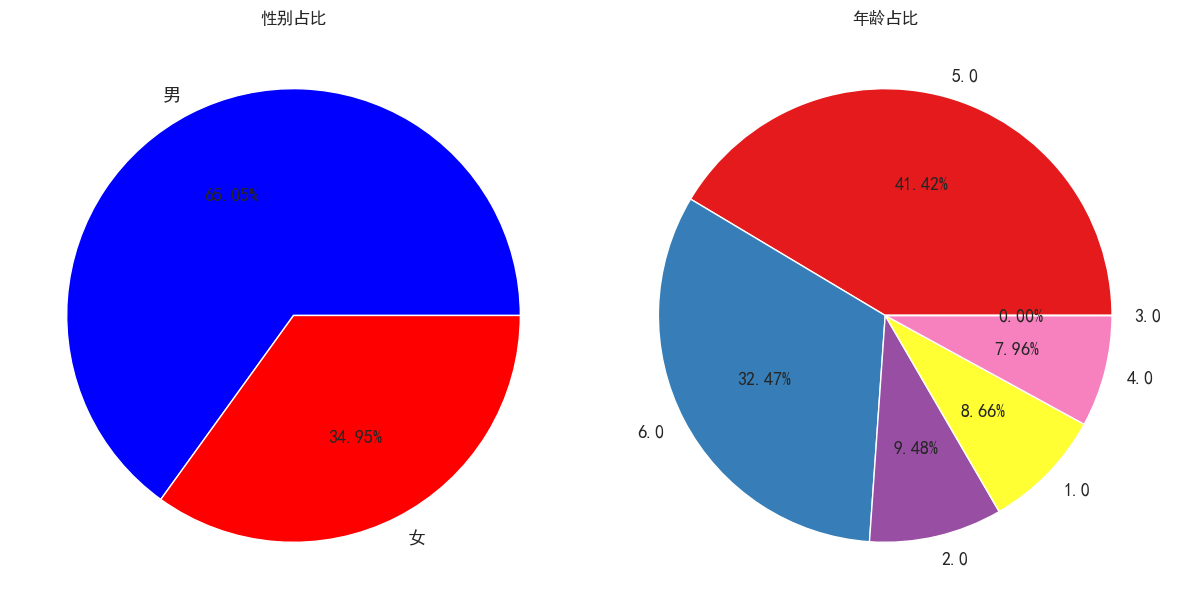

In [274]:
gender = df['性别'].value_counts()
print(gender)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
gender.plot.pie(autopct='%1.2f%%',colormap='bwr',fontsize=13,labels =['男','女'])
plt.title('性别占比',fontsize=12)
plt.ylabel('')

plt.subplot(1, 2, 2)
age_range = df['年龄范围'].value_counts()
age_range.plot.pie(autopct='%1.2f%%',colormap='Set1',fontsize=13)
plt.ylabel('')
plt.title('年龄占比',fontsize=12)
plt.tight_layout()
plt.show()

#### 可以看出用户大多数都是男性且年龄较成熟

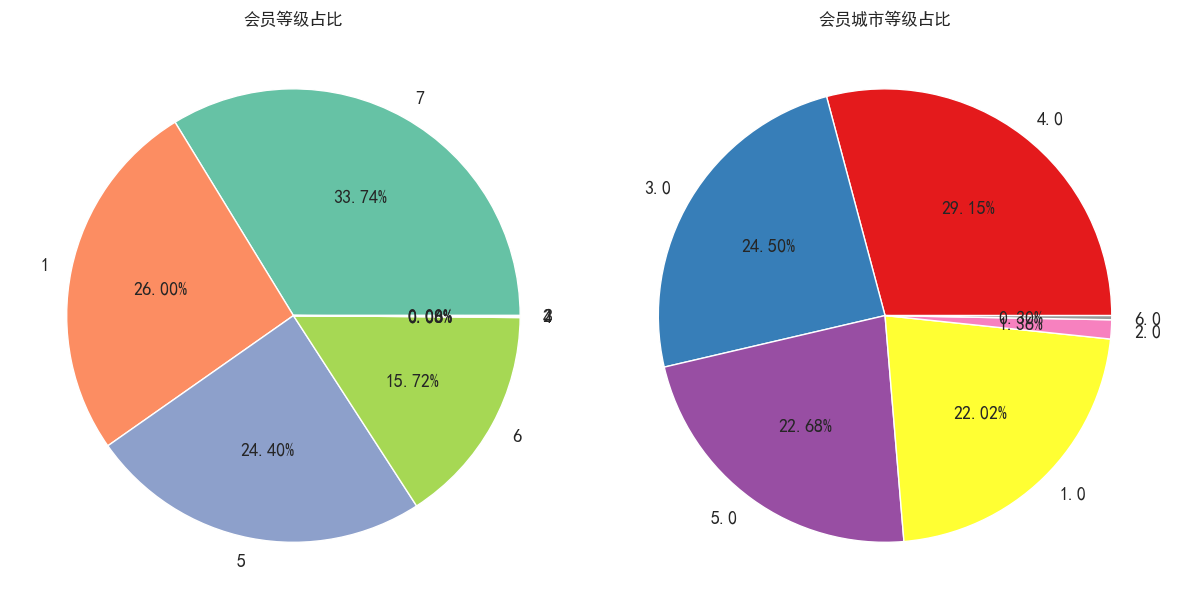

In [275]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
cust_level = df['客户等级'].value_counts()
cust_level.plot.pie(autopct='%1.2f%%',colormap='Set2',fontsize=13)
plt.title('会员等级占比',fontsize=12)
plt.ylabel('')

plt.subplot(1, 2, 2)
city_level1 = df['城市等级'].value_counts()
city_level1.plot.pie(autopct='%1.2f%%',colormap='Set1',fontsize=13)
plt.title('会员城市等级占比',fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

#### 可以看出大多数都是老用户，新用户只占了23%
#### 会员城市等级占比主要在1，3，4，5

Text(0.5, 1.0, '各年龄段性别分布')

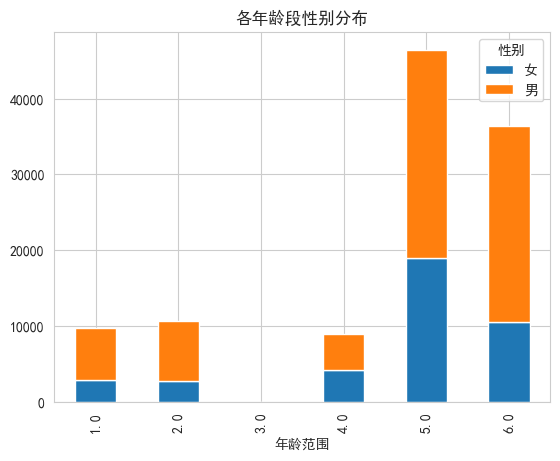

In [276]:
pd.crosstab(df['年龄范围'], df['性别']).plot(kind='bar', stacked=True)
plt.title('各年龄段性别分布')

####  每个年龄段的男性用户都多于女性用户，只有4.0和5.0的年龄段女性用户才接近和男性用户持平

Text(0.5, 0, '注册后天数')

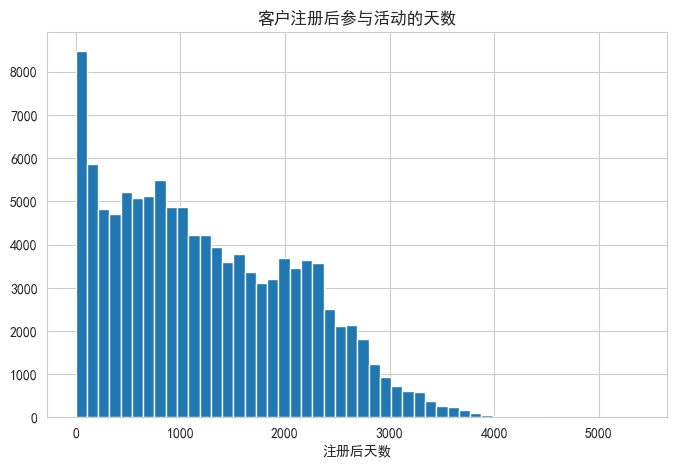

In [277]:
days = (df['活动日期'] - df['客户注册日期']).dt.days
days.hist(bins=50, figsize=(8, 5))
plt.title('客户注册后参与活动的天数')
plt.xlabel('注册后天数')

#### 可以看出用户在注册之后的2400天都是比较活跃的，之后就大幅下降，直到4000天就停止了

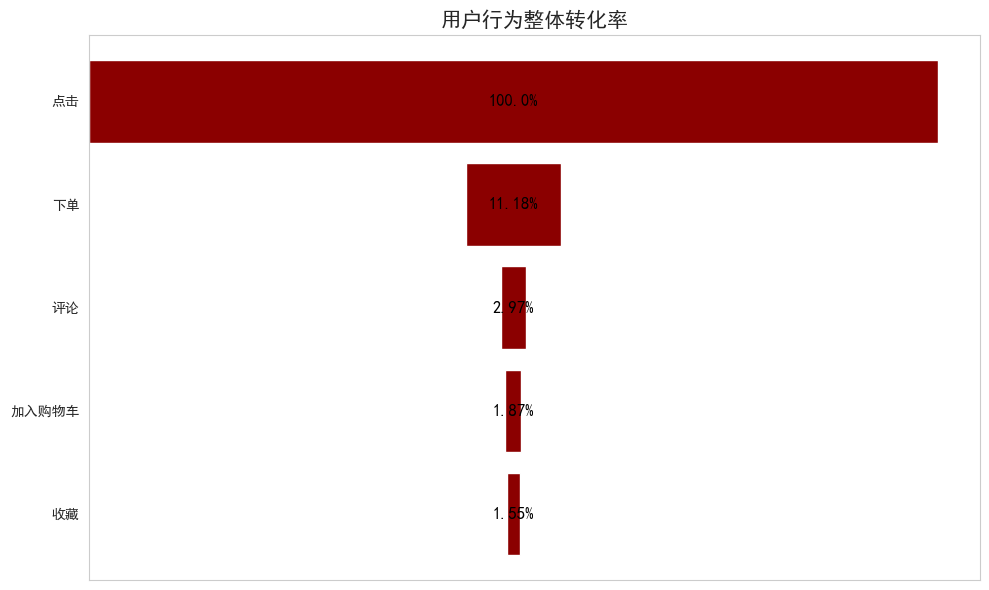

In [278]:
#用户整体转化率
user_act = df['用户行为'].dropna().value_counts().reset_index()
user_act.columns = ['用户行为', '行为数量']
user_act['转化率'] = (user_act['行为数量'] / user_act['行为数量'].iloc[0] * 100).round(2)

# 计算中点（让柱子从中间开始）
max_val = user_act['转化率'].max()
center = max_val / 2
# 画图
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(user_act['用户行为'], user_act['转化率'], left=center - user_act['转化率']/2, color='darkred')

# 显示百分比在柱子中间
for bar, rate in zip(bars, user_act['转化率']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
            f'{rate}%', ha='center', va='center', fontsize=12, fontweight='bold', color='black')

ax.invert_yaxis() # 逆序y轴
ax.set_xticks([]) # 去除x轴刻度
ax.set_title('用户行为整体转化率', fontsize=15)
ax.grid(False) # 去除网格线
plt.tight_layout()
plt.show()

#### 可以看出主要是加入购物车和收藏流失量较大，说明商品主图或者标题诱人但点进去之后没打动用户。
#### 下单6.53%这个数也不高，说明价格/运费/评价等方面让用户犹豫了

## 商品层面

Text(0.5, 1.0, '商品销售数量TOP10')

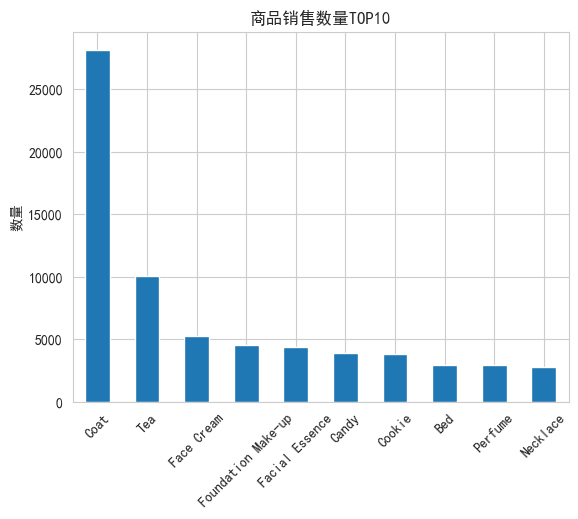

In [279]:
df['商品种类'].value_counts().sort_values(ascending=False).head(10).plot.bar()
plt.xticks(rotation=45)
plt.xlabel('')
plt.ylabel('数量')
plt.title('商品销售数量TOP10')

#### 可以看出Phone和Coat卖的最好，大幅领先其他商品

Text(0, 0.5, '购买数量')

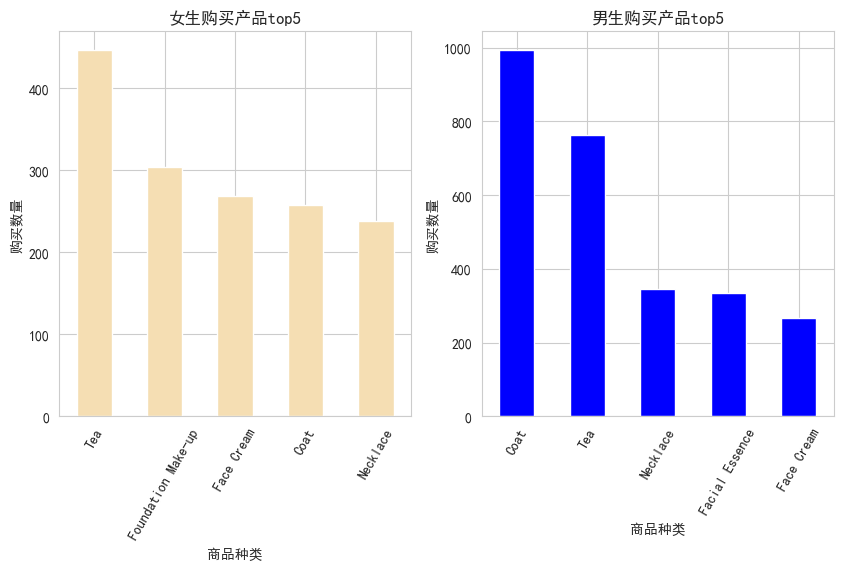

In [280]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
df.query('用户行为=="下单" and 性别=="女"').groupby('商品种类').size().sort_values(ascending=False).head().plot.bar(rot=60,color='wheat')
plt.title('女生购买产品top5')
plt.ylabel('购买数量')
plt.subplot(1, 2, 2)
df.query('用户行为=="下单" and 性别=="男"').groupby('商品种类').size().sort_values(ascending=False).head().plot.bar(rot=60,color='blue')
plt.title('男生购买产品top5')
plt.ylabel('购买数量')

#### 可以看出女生最爱买的产品是Tea，男生最爱买的产品是Coat

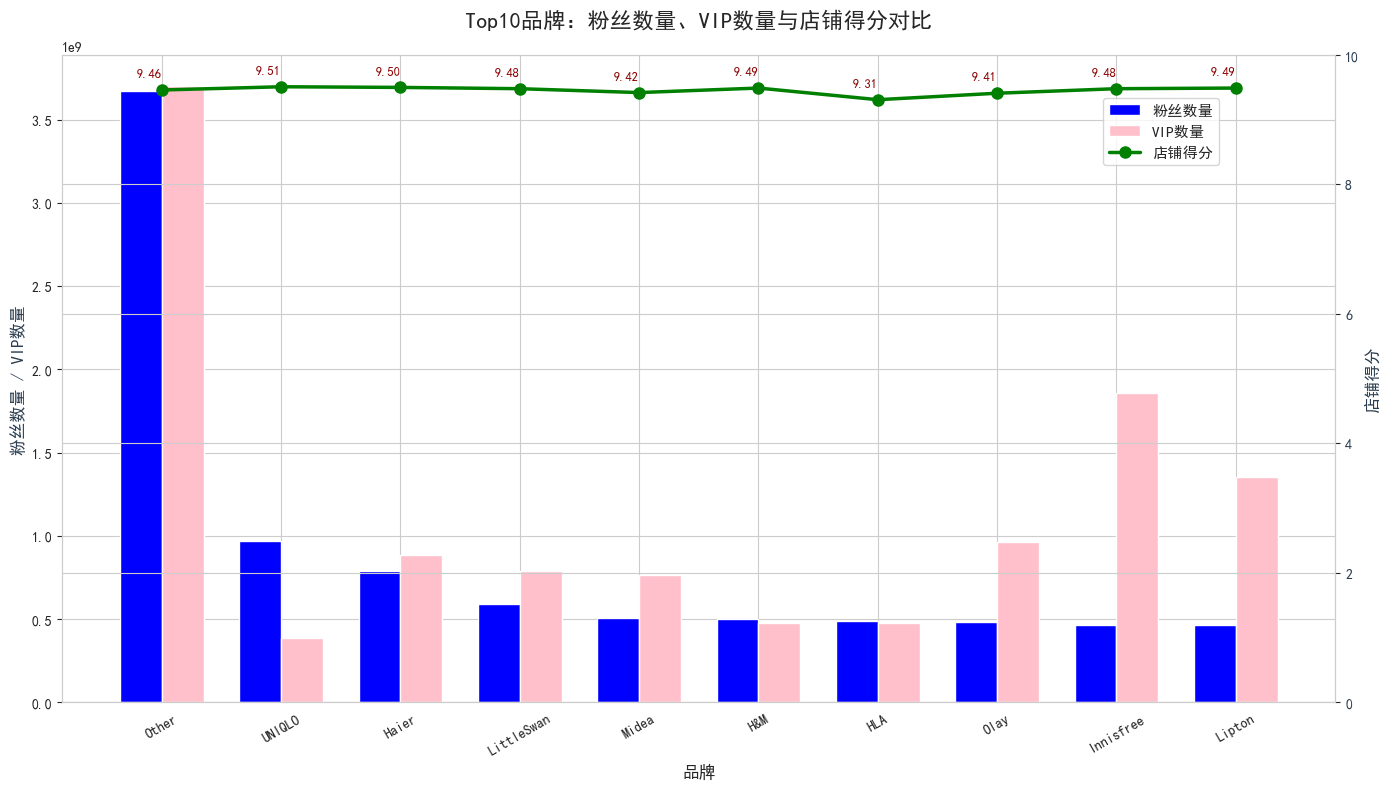

In [281]:
# 根据品牌，分别统计以下信息
all_data = df.groupby(['品牌']).agg({
    '客户ID': 'count',
    '店铺得分': 'mean',
    '粉丝数量': 'sum',
    'VIP数量': 'sum'
}).round(2).sort_values('粉丝数量',ascending=False).head(10)  #获取粉丝数量前十的品牌

# 可视化：粉丝数量,VIP数量:柱状图，商品得分:折线图，品牌:x轴
fig, ax1 = plt.subplots(figsize=(14, 8))

# 柱状图（左轴）
x = np.arange(len(all_data))
width = 0.35

bar1 = ax1.bar(x - width/2, all_data['粉丝数量'],width, label='粉丝数量', color='blue')
bar2 = ax1.bar(x + width/2, all_data['VIP数量'],width, label='VIP数量', color='pink')
ax1.set_xlabel('品牌', fontsize=12)
ax1.set_ylabel('粉丝数量 / VIP数量', fontsize=12, color='#2C3E50')
ax1.set_xticks(x)
ax1.set_xticklabels(all_data.index, fontsize=10, rotation=30)

# 折线图（右轴）
ax2 = ax1.twinx()
line = ax2.plot(x, all_data['店铺得分'], color='green', marker='o', linewidth=2.5, markersize=8, label='店铺得分')
ax2.set_ylabel('店铺得分', fontsize=12, color='#2C3E50')
ax2.tick_params(axis='y', labelcolor='#2C3E50')
ax2.set_ylim(0, 10)

# 在折线点上显示数值
for i, v in enumerate(all_data['店铺得分']):
    ax2.text(i, v + 0.2, f'{v:.2f}', ha='right', fontsize=9, color='darkred', fontweight='bold')

# 合并图例
bars = [bar1, bar2]
lines = line
labels = ['粉丝数量', 'VIP数量', '店铺得分']
plt.title('Top10品牌：粉丝数量、VIP数量与店铺得分对比', fontsize=16, pad=20)
fig.legend(bars + lines, labels, loc='upper right', bbox_to_anchor=(0.88, 0.88), fontsize=11)
plt.tight_layout()
plt.show()

#### 其他品牌的粉丝数量和VIP数量很多，但是商品得分相较于其他高粉丝量的品牌来说较低，不过这也是正常现象。
#### 除去其他品牌，可以看出top10的品牌商品得分基本相同，但是只有UNIQLO品牌的粉丝数量远大于VIP数量，其余品牌都是VIP数量多于或等于粉丝数量

# 店铺层面

Text(0, 0.5, '')

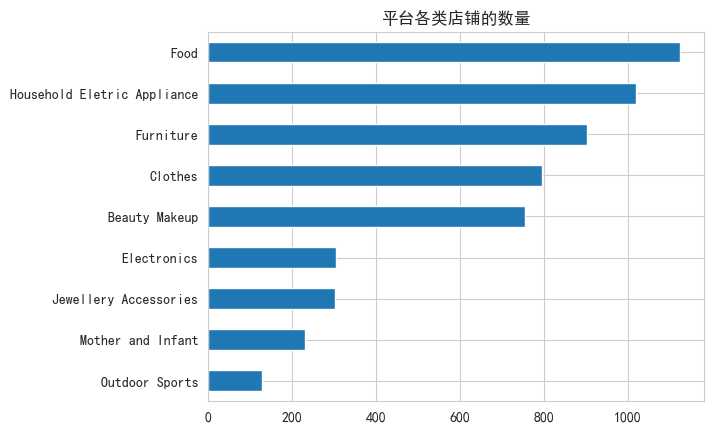

In [282]:
df.groupby('店铺种类')['店铺ID'].nunique().sort_values().head(10).plot.barh()
plt.title('平台各类店铺的数量')
plt.ylabel('')

#### 卖食物的店铺最多

In [283]:
df.groupby('店铺种类')['店铺得分'].mean()

店铺种类
Beauty Makeup                  9.500149
Clothes                        9.455459
Electronics                   -0.560836
Food                           9.472070
Furniture                      9.332357
Household Eletric Appliance    9.416171
Jewellery Accessories          9.423980
Mother and Infant              9.535807
Outdoor Sports                 9.533343
Name: 店铺得分, dtype: float64

#### Electronics有异常值

In [284]:
df.query('店铺种类 =="Electronics"')['店铺得分'].value_counts()

店铺得分
-1.000000     1296
 9.582667        8
 9.817166        5
 10.000000       4
 9.913987        4
 9.880256        3
 9.460123        3
 9.528500        3
 9.712239        2
 9.938892        2
 9.758765        2
 9.827818        2
 9.902624        2
 9.901035        2
 9.771972        1
 9.978210        1
 9.862955        1
 9.818970        1
 9.688882        1
 9.966540        1
 9.647588        1
 9.962323        1
 9.623666        1
 9.937288        1
 9.825688        1
 0.000000        1
 9.742332        1
 9.831441        1
Name: count, dtype: int64

#### 发现数据有问题，大部分都是负分，这是异常数据

Text(0.5, 1.0, '店铺得分分布')

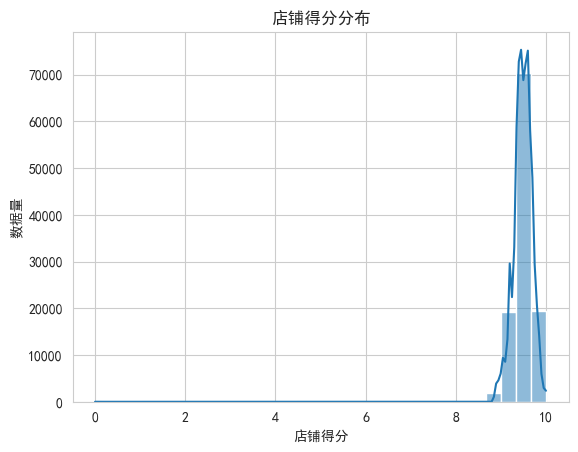

In [285]:
shop_socre = df[df['店铺得分'] >= 0 ]
sns.histplot(shop_socre['店铺得分'], kde=True, bins=30)
plt.ylabel('数据量')
plt.title('店铺得分分布')

#### 可以看出店铺得分要么0评分，要么高评分，这是较为正常的现象

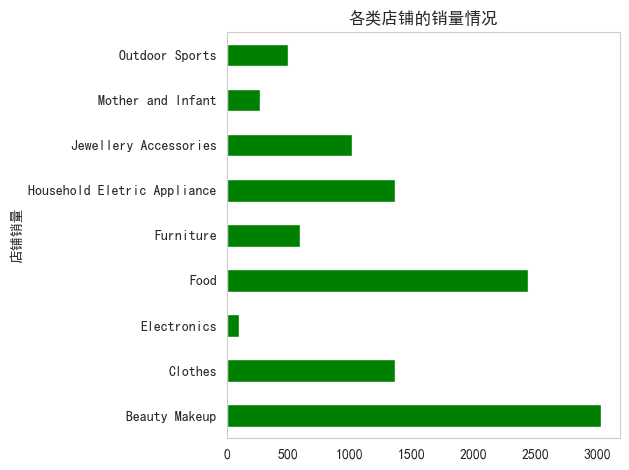

In [286]:
df.query('用户行为=="下单"').groupby('店铺种类').size().plot.barh(color='green')
plt.title('各类店铺的销量情况')
plt.ylabel('店铺销量')
plt.tight_layout()
plt.grid(False)